<a href="https://colab.research.google.com/github/jdasam/ant5015/blob/2026/notebooks/2nd_week_digital_audio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 — Digital Audio

## Overview

In this notebook we cover the fundamental concepts of digital audio representation and analysis:

1. **Loading audio** — reading a `.mp3` file with `torchaudio` and inspecting the waveform tensor.
2. **Playback** — listening to audio and slices thereof inside the notebook using `IPython.display`.
3. **Waveform visualization** — plotting raw sample values with `matplotlib`.
4. **Fourier Transform (FFT)** — computing the frequency spectrum of a short segment and understanding frequency-bin resolution.
5. **Short-Time Fourier Transform (STFT)** — implementing STFT from scratch with a sliding window (Hamming window, overlap-add).
6. **Spectrogram** — stacking FFT frames into a 2-D matrix and visualizing it as an image.

---

In [1]:
import torch
import torchaudio

In [2]:
!wget https://www.audiolabs-erlangen.de/resources/MIR/FMP/data/C3/FMP_C3_F03.mp3

--2026-03-11 06:33:28--  https://www.audiolabs-erlangen.de/resources/MIR/FMP/data/C3/FMP_C3_F03.mp3
Resolving www.audiolabs-erlangen.de (www.audiolabs-erlangen.de)... 131.188.16.201
Connecting to www.audiolabs-erlangen.de (www.audiolabs-erlangen.de)|131.188.16.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 589377 (576K) [audio/mpeg]
Saving to: ‘FMP_C3_F03.mp3’

FMP_C3_F03.mp3      100%[===================>] 575.56K  1010KB/s    in 0.6s    

2026-03-11 06:33:29 (1010 KB/s) - ‘FMP_C3_F03.mp3’ saved [589377/589377]



Load the audio file using `torchaudio` and store the waveform samples in `y` and the sampling rate in `sr`.

In [4]:
y, sr = torchaudio.load("FMP_C3_F03.mp3")

Print the shape of `y` (number of channels, total number of samples).

In [5]:
y.shape

torch.Size([1, 2149632])

Check `y.shape` (no output needed — assign to `None`).

In [6]:
num_samples = y.shape[1]
num_samples / sr

97.48897959183674

Play the audio file using `ipd.Audio`, then play it back at 2× speed for comparison.

In [12]:
import IPython.display as ipd
ipd.Audio(y, rate=sr)

Calculate the total duration of the audio in seconds.
- Hint: `num_sample / sr`

Slice the audio from 10 sec to 15 sec by converting seconds to sample indices, then play back the sliced segment.

In [16]:
sliced_audio = y[:, 10*sr:15*sr]
ipd.display(ipd.Audio(sliced_audio, rate=sr))

sliced_audio = y[:, 30*sr:35*sr]
ipd.Audio(sliced_audio, rate=sr)

Pick 1000 samples (indices 17000–18000) from the sliced audio and visualize the waveform with `plt.plot()`.

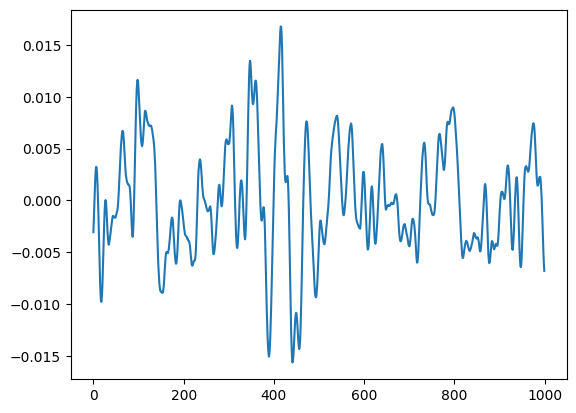

In [60]:
import matplotlib.pyplot as plt
sliced_audio = y[0, 5*sr:5*sr+1000]
plt.plot(sliced_audio)
ipd.Audio(sliced_audio, rate=sr)

Compute FFT using `torch.fft.fft()`, take the absolute value to discard phase, and plot only the positive-frequency half.

In [61]:
spectrum = torch.fft.fft(sliced_audio).abs()
spectrum.shape

torch.Size([1000])

Plot only the positive-frequency half of the FFT result.

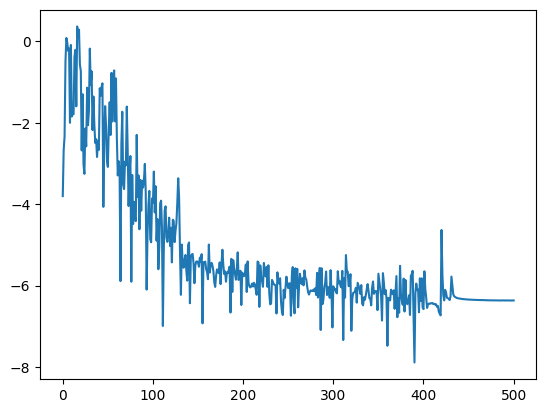

In [62]:
plt.plot(spectrum[:501].log())

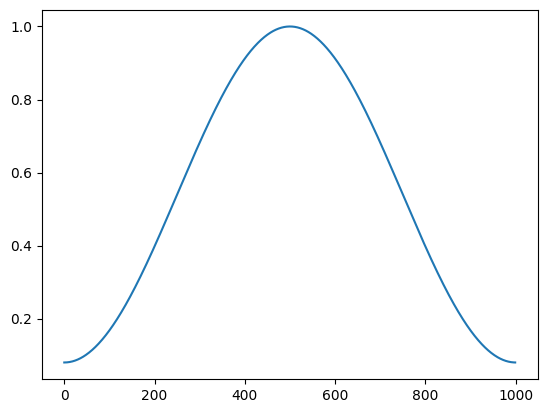

In [63]:
window = torch.hamming_window(1000)
plt.plot(window)

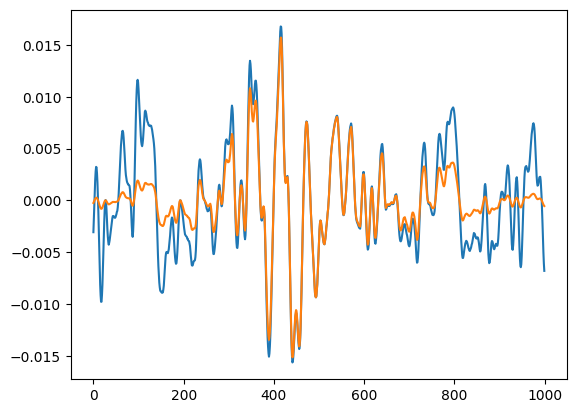

In [64]:
windowed_audio = sliced_audio * window
plt.plot(sliced_audio)
plt.plot(windowed_audio)

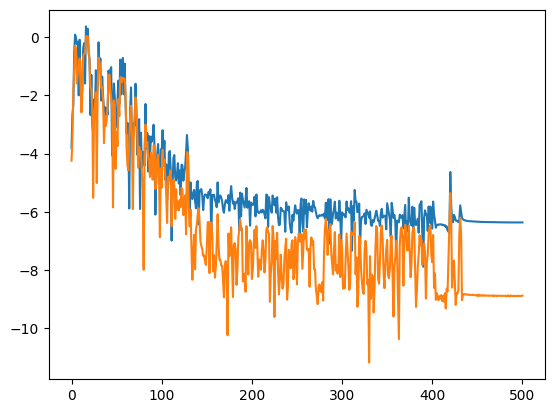

In [65]:
windowed_spectrum = torch.fft.fft(windowed_audio).abs()
plt.plot(spectrum[:501].log())
plt.plot(windowed_spectrum[:501].log())

Calculate the frequency bin resolution (`freq_bin_resolution = sr / window_size`) and plot the first 100 bins.

22.05


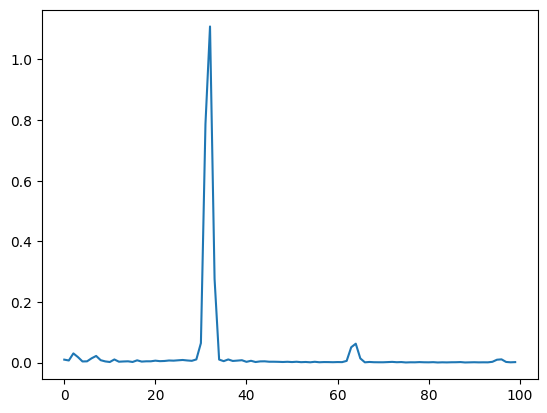

In [52]:
freq_bin_resolution = sr / 1000
print(freq_bin_resolution)

plt.plot(windowed_spectrum[:100])

Recompute FFT with a longer window (2000 samples) and plot the result on a log scale.

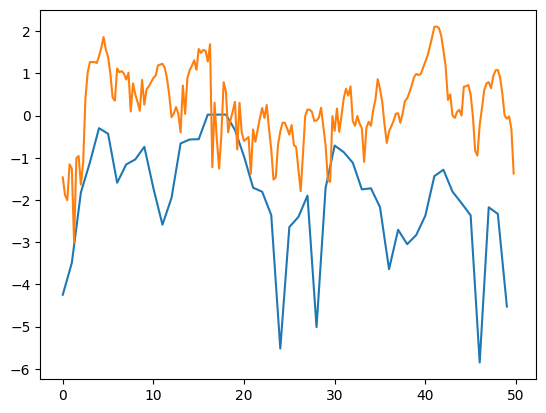

In [68]:
window_size = 4000
sliced_audio = y[0, 5*sr:5*sr+window_size]
windowed_audio = sliced_audio * torch.hamming_window(window_size)

windowed_spectrum_long = torch.fft.fft(windowed_audio).abs()
# plt.plot(spectrum[:501].log())
plt.plot(torch.arange(50), windowed_spectrum[:50].log())
plt.plot(torch.arange(200)/4,windowed_spectrum_long[:200].log())


Play back `detailed_example` using `ipd.Audio`.

In [78]:
spectrogram = []

window_size = 2000
hop_size = 500

for start_sample_index in range(0, y.shape[1]-window_size, hop_size):
  # print(start_sample_index)
  sliced_audio = y[0, start_sample_index : start_sample_index + window_size]
  windowed_audio = sliced_audio * torch.hamming_window(window_size)
  windowed_spectrum = torch.fft.fft(windowed_audio).abs()
  spectrogram.append(windowed_spectrum[:window_size//2+1])

In [79]:
spectrogram = torch.stack(spectrogram)
spectrogram.shape

torch.Size([4296, 1001])

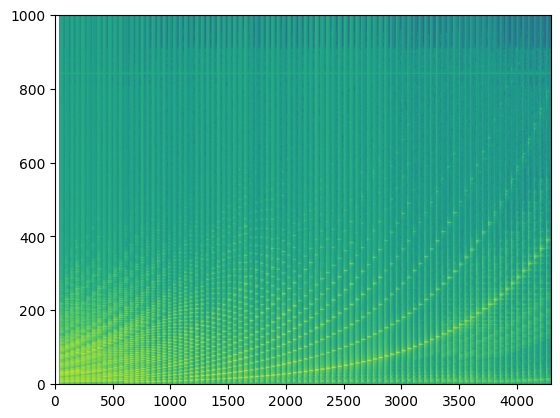

In [80]:
plt.imshow(spectrogram.log().T, aspect='auto', origin='lower')

Implement STFT manually using a for-loop.
- Set `window_size = 2048`, `hop_size = 1024`, and use a Hamming window (`torch.hamming_window`).
- For each frame: multiply the signal by the window function, apply FFT, and append the result to an `output` list.

Plot the Hamming window function, the raw audio signal, and their element-wise product (windowed signal) on the same axes.

Print the length of `output` (number of time frames) and compare `hop_size * len(output)` against the total sample count.

Stack the tensors in `output` using `torch.stack` to build a spectrogram matrix of shape `[freq_bins × time_frames]`.

Check the maximum value and mean value of the spectrogram.

Visualize the spectrogram on a log scale using `plt.imshow()` with `figsize=(20, 10)` and `origin='lower'`.